# Kaggle Titanic 预测模型训练

## Initial

In [24]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import os

In [25]:

for dirname, _, filenames in os.walk('../data/titanic'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

../data/titanic\gender_submission.csv
../data/titanic\test.csv
../data/titanic\train.csv


## Get Train & Test Data

In [26]:
train_data = pd.read_csv('../data/titanic/train.csv')
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [27]:
test_data = pd.read_csv('../data/titanic/test.csv')
test_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


## Data Preprocessing

In [29]:
y = train_data["Survived"]  # 定义标签
features = ["Pclass", "Sex", "SibSp", "Parch", "Age", "Embarked", "Ticket"]  # 预测特征

train_features = train_data[features].copy()
test_features = test_data[features].copy()

# Ticket 中有纯数字票号，也有带字母/符号的票号；这里提取最后一段数字作为 TicketNumber
train_features["TicketNumber"] = train_features["Ticket"].astype(str).str.extract(r"(\d+)\s*$")[0].astype(float)
test_features["TicketNumber"] = test_features["Ticket"].astype(str).str.extract(r"(\d+)\s*$")[0].astype(float)

ticket_number_median = pd.concat([
    train_features["TicketNumber"],
    test_features["TicketNumber"],
]).median()

train_features["TicketNumber"] = train_features["TicketNumber"].fillna(ticket_number_median)
test_features["TicketNumber"] = test_features["TicketNumber"].fillna(ticket_number_median)
train_features = train_features.drop(columns="Ticket")
test_features = test_features.drop(columns="Ticket")

X = pd.get_dummies(train_features)
X_test = pd.get_dummies(test_features)
X_test = X_test.reindex(columns=X.columns, fill_value=0)

X.head()

,Pclass,SibSp,Parch,Age,TicketNumber,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,3,1,0,22.0,21171.0,False,True,False,False,True
1,1,1,0,38.0,17599.0,True,False,True,False,False
2,3,0,0,26.0,3101282.0,True,False,False,False,True
3,1,1,0,35.0,113803.0,True,False,False,False,True
4,3,0,0,35.0,373450.0,False,True,False,False,True


## Random Forest

In [36]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=2500, max_depth=5, random_state=1)  # 100个基学习器，每棵树最多五层
model.fit(X, y)
predictions = model.predict(X_test)

output = pd.DataFrame({'PassengerId': test_data.PassengerId, 'Survived': predictions})
output.to_csv('../outputs/titanic/submission.csv', index=False)
print("Your submission was successfully saved!")

Your submission was successfully saved!


## Boosting

In [37]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

X_test = X_test.reindex(columns=X.columns, fill_value=0)

boosting_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", GradientBoostingClassifier(
        n_estimators=2000,
        learning_rate=0.05,
        max_depth=5,
        random_state=1,
    )),
])

boosting_model.fit(X, y)
boosting_predictions = boosting_model.predict(X_test)

boosting_output = pd.DataFrame({
    "PassengerId": test_data.PassengerId,
    "Survived": boosting_predictions,
})
os.makedirs("../outputs/titanic", exist_ok=True)
boosting_output.to_csv("../outputs/titanic/boosting_submission.csv", index=False)
print("Boosting submission was successfully saved!")

Boosting submission was successfully saved!


## 数据分析与可视化

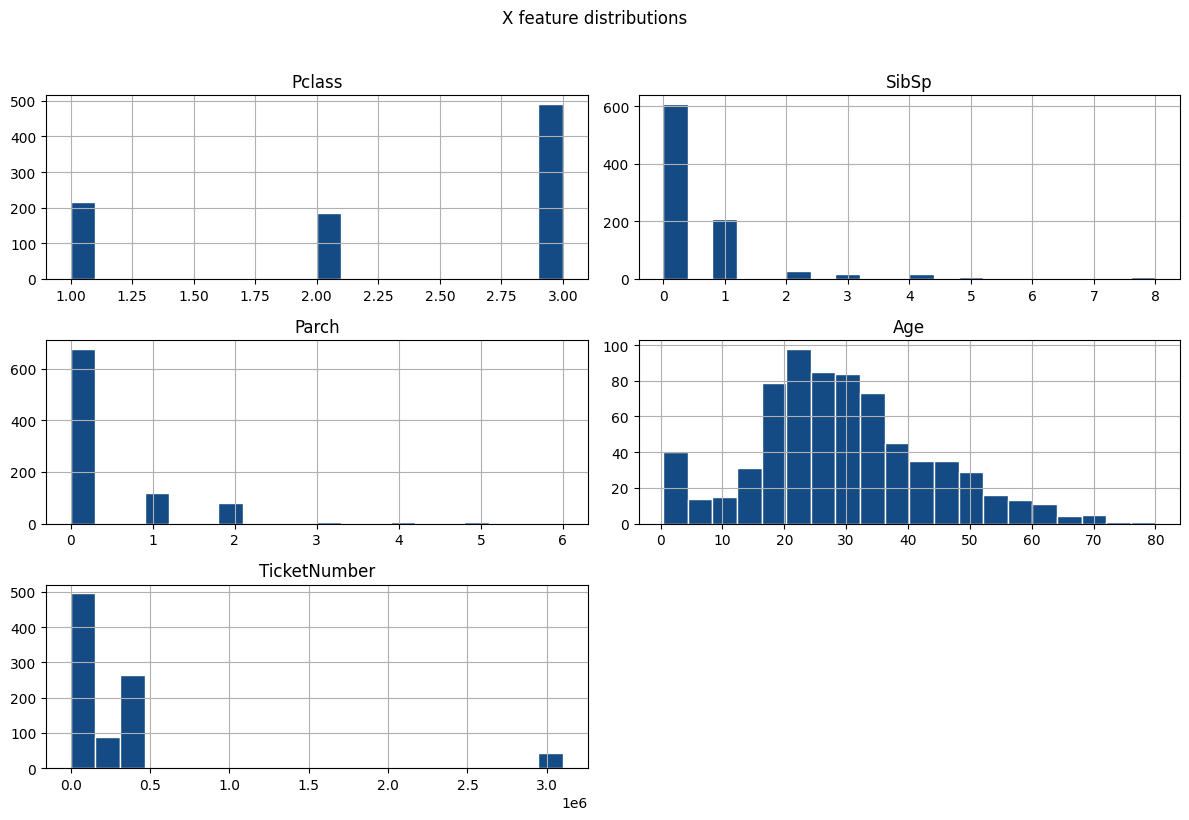

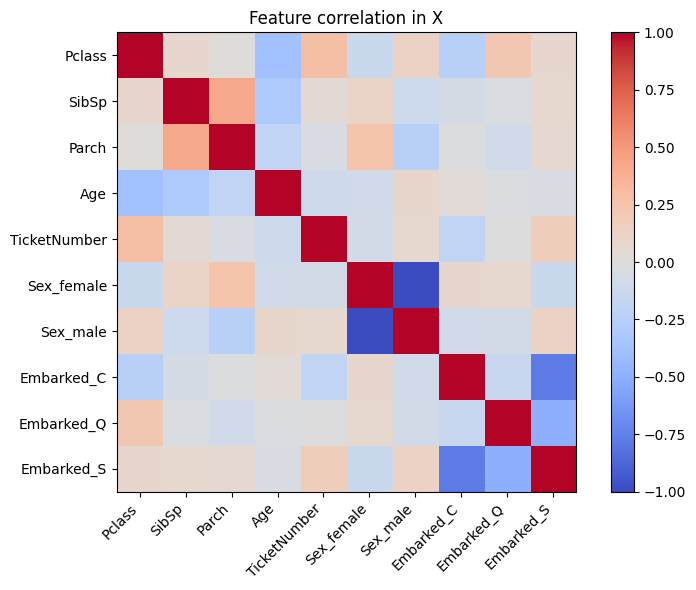

In [31]:
X.hist(figsize=(12, 8), bins=20, color="#144B85", edgecolor="white")
plt.suptitle("X feature distributions", y=1.02)
plt.tight_layout()
plt.show()

corr = X.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_title("Feature correlation in X")
ax.set_xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr.columns)), corr.columns)
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

,CabinDeck,survival_rate,passenger_count
0,A,0.466667,15
1,B,0.744681,47
2,C,0.593220,59
3,D,0.757576,33
4,E,0.750000,32
5,F,0.615385,13
6,G,0.500000,4
7,T,0.000000,1
8,U,0.299854,687


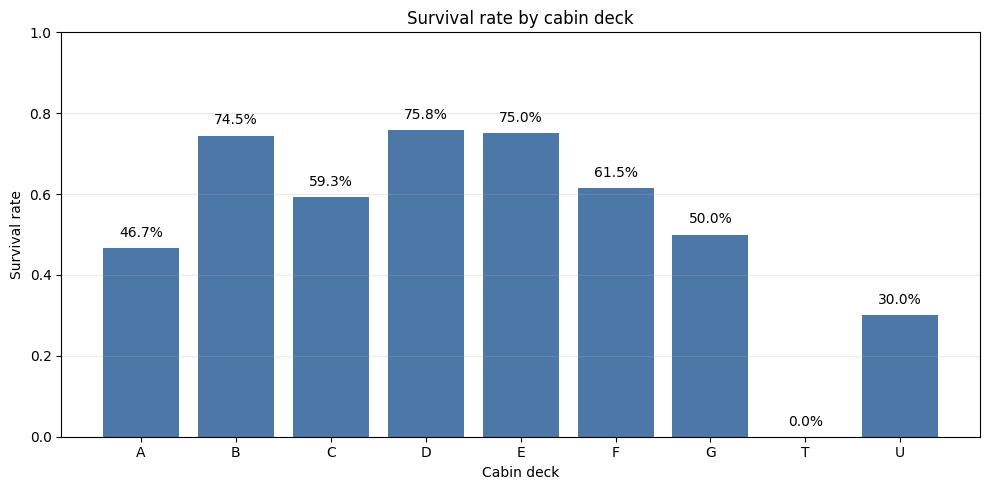

In [32]:
# 舱号-幸存者分析
cabin_survival = train_data.copy()
cabin_survival["CabinDeck"] = cabin_survival["Cabin"].fillna("Unknown").str[0]

cabin_stats = (
    cabin_survival.groupby("CabinDeck")
    .agg(
        survival_rate=("Survived", "mean"),
        passenger_count=("Survived", "size"),
    )
    .reset_index()
    .sort_values("CabinDeck")
)

display(cabin_stats)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(cabin_stats["CabinDeck"], cabin_stats["survival_rate"], color="#4C78A8")

ax.set_title("Survival rate by cabin deck")
ax.set_xlabel("Cabin deck")
ax.set_ylabel("Survival rate")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.25)

for bar, rate in zip(bars, cabin_stats["survival_rate"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{rate:.1%}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()
